=== Persentase Pendapatan >50K berdasarkan Gender ===
sex
Female    10.95 %
Male      30.57 %
Name: income_high, dtype: object


=== Persentase Pendapatan >50K berdasarkan Ras ===
race
Amer-Indian-Eskimo    11.58 %
Asian-Pac-Islander    26.56 %
Black                 12.39 %
Other                  9.23 %
White                 25.59 %
Name: income_high, dtype: object


/tmp/ipykernel_1593/398973847.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=gender_prop.index, y=gender_prop.values, palette='Set1')
/tmp/ipykernel_1593/398973847.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=race_prop.index, y=race_prop.values, palette='Set2')


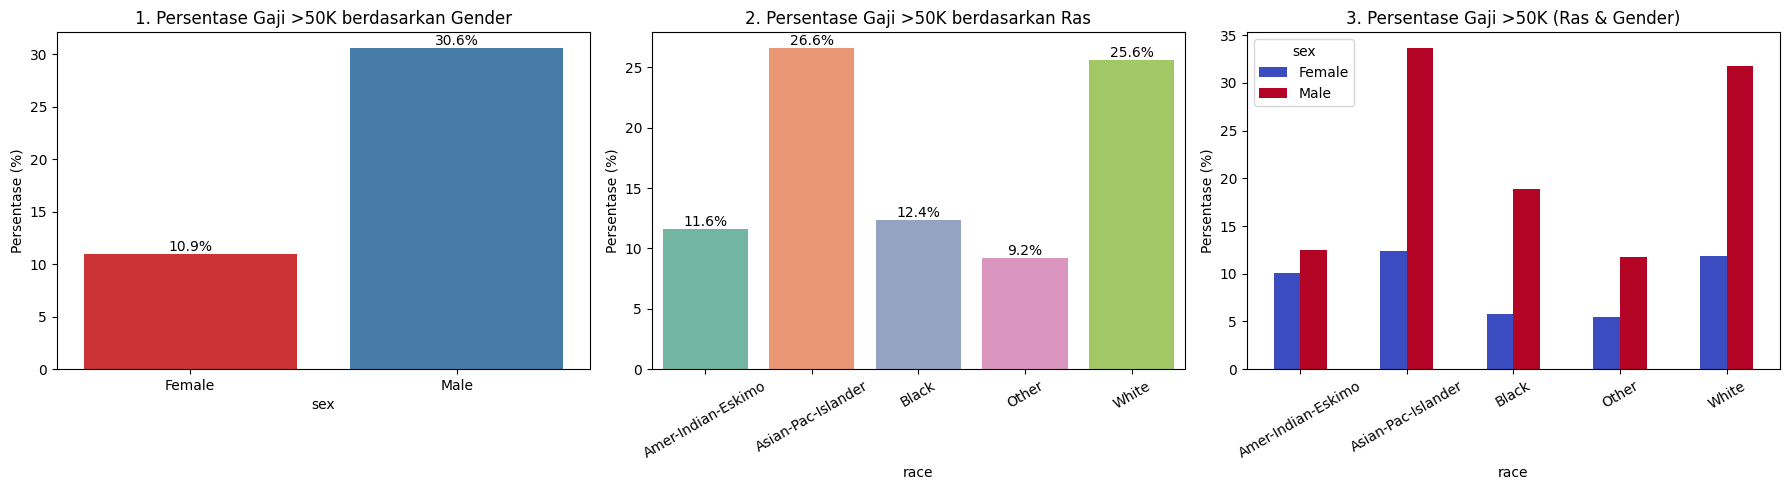

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset Adult Income langsung dari UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=columns, skipinitialspace=True)

# Preprocessing singkat kolom income
df['income_high'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

# 1. Hitung Proporsi Pendapatan >50K berdasarkan Gender
gender_prop = df.groupby('sex')['income_high'].mean() * 100
print("=== Persentase Pendapatan >50K berdasarkan Gender ===")
print(gender_prop.round(2).astype(str) + " %")
print("\n")

# 2. Hitung Proporsi Pendapatan >50K berdasarkan Ras
race_prop = df.groupby('race')['income_high'].mean() * 100
print("=== Persentase Pendapatan >50K berdasarkan Ras ===")
print(race_prop.round(2).astype(str) + " %")

# 3. Membuat 3 Visualisasi Ketimpangan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1: Proporsi >50K berdasarkan Sex
sns.barplot(ax=axes[0], x=gender_prop.index, y=gender_prop.values, palette='Set1')
axes[0].set_title('1. Persentase Gaji >50K berdasarkan Gender')
axes[0].set_ylabel('Persentase (%)')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Grafik 2: Proporsi >50K berdasarkan Ras
sns.barplot(ax=axes[1], x=race_prop.index, y=race_prop.values, palette='Set2')
axes[1].set_title('2. Persentase Gaji >50K berdasarkan Ras')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Grafik 3: Kombinasi Ras & Gender terhadap Gaji >50K
combo_prop = df.groupby(['race', 'sex'])['income_high'].mean().unstack() * 100
combo_prop.plot(kind='bar', ax=axes[2], colormap='coolwarm')
axes[2].set_title('3. Persentase Gaji >50K (Ras & Gender)')
axes[2].set_ylabel('Persentase (%)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()